<div align="center">

# Notebook 6 Upgrade

# Classification multi-class FOCH

**Transfer Learning VoxCeleb — Branche Dual pour la classification**

![Python](https://img.shields.io/badge/Python-3.10+-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.0+-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)

</div>


## 1. Configuration de l'environnement et des chemins

Cette première section centralise les dépendances et les chemins. Le notebook met en œuvre un **modèle de fusion bi-branche** (WavLM-Large + ResNetSE34L VoxCeleb) évalué par **validation croisée stratifiée à 5 plis** (`StratifiedKFold`), avec **augmentation de données injectée pli par pli dans le seul jeu d'entraînement**.

**Améliorations apportées dans cette version :**

| Amélioration | Description |
|---|---|
| **Dégel progressif ResNetSE34L** | Commence entièrement gelé ; les blocs sont débloqués de haut en bas (layer4→layer3→layer2→stem) selon `RESNET_UNFREEZE_SCHEDULE` |
| **Dégel progressif WavLM** | Idem : couches Transformer 18-23 → 12-17 → 0-11 + CNN selon `WAVLM_UNFREEZE_SCHEDULE`, avec LR décroissant par couche (*layer-wise LR decay*) |
| **SpecAugment sur WavLM** | WavLM opère sur la forme d'onde brute, pas sur un spectrogramme. Le SpecAugment est appliqué sur la **sortie du feature extractor CNN** (B, T′, 512) : masques temporels (T′) et masques de canaux (512-dim) — équivalent direct du SpecAugment classique (Park et al. 2019) adapté à l'espace de features latentes |
| **Ensembling K modèles** | À l'inférence, les K checkpoints sont chargés l'un après l'autre et leurs probabilités sont **moyennées** (soft voting), réduisant la variance par rapport à un modèle unique |

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1 — Imports, configuration des chemins et hyperparamètres (v2)
# ═══════════════════════════════════════════════════════════════════════════
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')  # [Change 5] set before CUDA init
import gc
import glob
import random
import sys
import warnings

import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# [Change 4] 8-bit optimizer — graceful fallback if bitsandbytes absent
try:
    import bitsandbytes as bnb
    BNB_AVAILABLE = True
except ImportError:
    BNB_AVAILABLE = False
    print('[warn] bitsandbytes not found – falling back to standard AdamW. '
          'pip install bitsandbytes to enable 8-bit optimizer.')

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── FFmpeg (backend de décodage audio pour torchaudio) ───────────────────────
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── Chemin du trainer VoxCeleb (ajouté au sys.path pour importer ResNetSE34L) ─
VOXCELEB_TRAINER_DIR = r'C:/Users/AdminIA/Desktop/Vox_celeb/voxceleb_trainer'
if VOXCELEB_TRAINER_DIR not in sys.path:
    sys.path.insert(0, VOXCELEB_TRAINER_DIR)

# ── Chemins des données ──────────────────────────────────────────────────────
CSV_PATH        = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/csv_best/orl_df_vowel_master.csv'
FOCH_AUDIO_DIR  = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'

# ── Données augmentées ────────────────────────────────────────────────────────
AUG_DIR         = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented'
AUG_SIGNAL_DIR  = os.path.join(AUG_DIR, 'signal')
AUG_MANIFESTS   = [
    os.path.join(AUG_DIR, 'manifest_train_bal.csv'),
    os.path.join(AUG_DIR, 'manifest_train_bal_vc.csv'),
]

# ── Backbones et artefacts de sortie ─────────────────────────────────────────
MODEL_DIR   = r'C:/Users/AdminIA/Documents/models/wavlm-large'
WEIGHTS_DIR = r'C:/Users/AdminIA/Documents/models/.poids_modèles'
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_métriques'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = 'wavlm_voxceleb_kfold_aug_v2'

# ── Poids VoxCeleb pré-entraînés ─────────────────────────────────────────────
VOXCELEB_CKPT_PATH  = r'C:/Users/AdminIA/Desktop/Vox_celeb/voxceleb_trainer/baseline_lite_ap.model'
VOXCELEB_PRETRAINED = True
VOXCELEB_EMB_DIM    = 512

# ── Définition des classes ───────────────────────────────────────────────────
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]
NUM_LABELS         = len(CLASSES)
N_HEALTHY          = 100

# ── Validation croisée ────────────────────────────────────────────────────────
K_FOLDS      = 5

# ── Hyperparamètres audio ─────────────────────────────────────────────────────
TARGET_SR    = 16000
MAX_LEN_S    = 3.0    # [Change 3] was 4.0 — T' ~150 frames @ 3 s vs ~200 @ 4 s
MAX_LEN      = int(TARGET_SR * MAX_LEN_S)

# ── Hyperparamètres d'entraînement ────────────────────────────────────────────
BATCH_SIZE      = 2    # [Change 3] was 4; effective = BATCH_SIZE × ACCUM_STEPS = 16
ACCUM_STEPS     = 8    # [Change 3] was 4; 2 × 8 = 16 — effective batch unchanged
EPOCHS          = 40    # Augmenté pour accommoder le dégel progressif
LR              = 1e-4
WEIGHT_DECAY    = 0.01
PATIENCE        = 8     # Augmenté : le dégel progressif peut provoquer un creux temporaire
DROPOUT         = 0.3
HIDDEN_DIM      = 512

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Dégel progressif — ResNetSE34L ───────────────────────────────────────────
# Les deux backbones démarrent entièrement gelés. Seule la tête de fusion est
# entraînable lors des premières epochs. Le dégel s'effectue de haut en bas
# (couches fines → couches grossières) pour éviter de détruire les features
# appris sur VoxCeleb.
# Format : (epoch_debut, [patterns_de_noms_de_modules], lr_du_groupe)
RESNET_UNFREEZE_SCHEDULE = [
    (4,  ['attention', 'bn5', 'fc6', 'bn6'],   LR * 0.5),   # Tête ResNet (SAP + sortie)
    (6,  ['layer4'],                            LR * 0.1),   # Dernier bloc résiduel
    (9,  ['layer3'],                            LR * 0.05),  # Avant-dernier bloc
    (13, ['layer2', 'layer1', 'conv1', 'bn1'], LR * 0.02),  # Couches inférieures + tige
]

# ── Dégel progressif — WavLM-Large (24 couches Transformer) ──────────────────
# WavLM-Large est aussi gelé dès le départ. Les couches supérieures (plus
# spécifiques à la tâche) sont dégelées en premier, avec un LR très faible pour
# ne pas perturber les représentations pré-entraînées.
# [Change 2] Tier 3 (epoch 17 — layers 0-11 + feature_extractor, ~309 M params)
# removed to stay within 8 GB VRAM once the two shallower tiers are active.
WAVLM_UNFREEZE_SCHEDULE = [
    (6,  (['encoder.layers.18', 'encoder.layers.19', 'encoder.layers.20',
            'encoder.layers.21', 'encoder.layers.22', 'encoder.layers.23',
            'feature_projection']),                                        LR * 0.02),
    (11, (['encoder.layers.12', 'encoder.layers.13', 'encoder.layers.14',
            'encoder.layers.15', 'encoder.layers.16', 'encoder.layers.17']), LR * 0.01),
]

# ── SpecAugment sur les features CNN de WavLM ────────────────────────────────
# WavLM opère sur la forme d'onde brute et n'a pas de spectrogramme. Le
# SpecAugment est ici appliqué sur la SORTIE du feature extractor CNN (B, T', 512),
# soit après la convolution 1D et avant le Transformer :
#   • masques temporels  → zèrent des blocs consécutifs dans T' (~150 frames pour 3 s)
#   • masques de canaux  → zèrent des blocs consécutifs dans les 512 canaux CNN
# Ceci est l'équivalent direct du SpecAugment de Park et al. (2019) adapté à
# l'espace de features latentes de WavLM (pas à un spectrogramme 2D).
USE_SPEC_AUGMENT    = True
SA_N_TIME_MASKS     = 2    # nombre de masques temporels par exemple
SA_TIME_MASK_PARAM  = 30   # longueur max d'un masque temporel (en frames CNN, T' ~ 150)
SA_N_FREQ_MASKS     = 2    # nombre de masques de canaux par exemple
SA_FREQ_MASK_PARAM  = 64   # largeur max d'un masque de canaux (sur 512 canaux)

# ── Ensembling des K modèles à l'inférence ────────────────────────────────────
ENSEMBLE_TEMPERATURE = 1.0   # température du softmax (1.0 = pas de lissage)

# ── Résumé de la configuration ───────────────────────────────────────────────
if not VOXCELEB_PRETRAINED:
    _vc_status = 'initialisation ALÉATOIRE'
elif VOXCELEB_CKPT_PATH and os.path.isfile(VOXCELEB_CKPT_PATH):
    _vc_status = f'chemin LOCAL → {VOXCELEB_CKPT_PATH}'
else:
    _vc_status = f'FICHIER INTROUVABLE → initialisation aléatoire'

print('Configuration v2 chargée.')
print(f'  Classes ({NUM_LABELS})   : {CLASSES}')
print(f'  Backbone WavLM   : {MODEL_DIR}')
print(f'  Fusion dim       : 1024 (WavLM) + {VOXCELEB_EMB_DIM} (ResNetSE34L) = {1024 + VOXCELEB_EMB_DIM}')
print(f'  VoxCeleb poids   : {_vc_status}')
print(f'  Dégel ResNet     : {len(RESNET_UNFREEZE_SCHEDULE)} étapes (epochs {[e for e,_,_ in RESNET_UNFREEZE_SCHEDULE]})')
print(f'  Dégel WavLM      : {len(WAVLM_UNFREEZE_SCHEDULE)} étapes (epochs {[e for e,_,_ in WAVLM_UNFREEZE_SCHEDULE]}) — tier profond désactivé')
print(f'  Batch / accum    : {BATCH_SIZE} × {ACCUM_STEPS} = {BATCH_SIZE * ACCUM_STEPS} effectif | MAX_LEN_S={MAX_LEN_S} s')
print(f'  Optimizer 8-bit  : {"bitsandbytes AdamW8bit" if BNB_AVAILABLE else "AdamW standard (bitsandbytes absent)"}')
print(f'  SpecAugment      : {"Activé" if USE_SPEC_AUGMENT else "Désactivé"} '
      f'(T={SA_N_TIME_MASKS}×{SA_TIME_MASK_PARAM}, F={SA_N_FREQ_MASKS}×{SA_FREQ_MASK_PARAM})')
print(f'  Ensembling       : {K_FOLDS} modèles — température {ENSEMBLE_TEMPERATURE}')
print(f'  Device           : {device}')


bitsandbytes library load error: Configured CUDA binary not found at c:\Users\AdminIA\Desktop\ORL_IA_FOCH_Callum_HOLLIDAY\.orl_ia\Lib\site-packages\bitsandbytes\libbitsandbytes_cuda132.dll
Traceback (most recent call last):
  File "c:\Users\AdminIA\Desktop\ORL_IA_FOCH_Callum_HOLLIDAY\.orl_ia\Lib\site-packages\bitsandbytes\cextension.py", line 320, in <module>
    lib = get_native_library()
  File "c:\Users\AdminIA\Desktop\ORL_IA_FOCH_Callum_HOLLIDAY\.orl_ia\Lib\site-packages\bitsandbytes\cextension.py", line 288, in get_native_library
    raise RuntimeError(f"Configured {BNB_BACKEND} binary not found at {cuda_binary_path}")
RuntimeError: Configured CUDA binary not found at c:\Users\AdminIA\Desktop\ORL_IA_FOCH_Callum_HOLLIDAY\.orl_ia\Lib\site-packages\bitsandbytes\libbitsandbytes_cuda132.dll
W0701 10:18:13.101000 11592 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration v2 chargée.
  Classes (4)   : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Backbone WavLM   : C:/Users/AdminIA/Documents/models/wavlm-large
  Fusion dim       : 1024 (WavLM) + 512 (ResNetSE34L) = 1536
  VoxCeleb poids   : chemin LOCAL → C:/Users/AdminIA/Desktop/Vox_celeb/voxceleb_trainer/baseline_lite_ap.model
  Dégel ResNet     : 4 étapes (epochs [4, 6, 9, 13])
  Dégel WavLM      : 2 étapes (epochs [6, 11]) — tier profond désactivé
  Batch / accum    : 2 × 8 = 16 effectif | MAX_LEN_S=3.0 s
  Optimizer 8-bit  : bitsandbytes AdamW8bit
  SpecAugment      : Activé (T=2×30, F=2×64)
  Ensembling       : 5 modèles — température 1.0
  Device           : cuda


## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 2 — Parsing des métadonnées, nettoyage et appariement Saarbruecken
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Lecture des métadonnées FOCH ──────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
print(f'Métadonnées brutes            : {len(df_meta):>4} lignes')

# ── 2. Normalisation défensive des chaînes de caractères ─────────────────────
# Les libellés VSL comportent du bruit : espaces parasites ('Cancer ' vs
# 'Cancer'), valeurs vides/NaN, point d'interrogation. Ce nettoyage systématique
# évite les erreurs d'appariement silencieuses sur les libellés de pathologie.
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()

# Clé d'appariement insensible à la casse pour les libellés de pathologie
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

# ── 3. Filtrage sur les classes cibles du baseline ───────────────────────────
# Dictionnaire { libellé_normalisé : libellé_canonique } pour réattribuer
# proprement le nom de classe officiel après le filtrage.
target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)
print(f'Lignes pathologiques retenues : {len(df_patho):>4}  (PR / LMB / fuite glottique)')

# ── 4. Déduplication au niveau patient (clé = Last_Name) ─────────────────────
# Un même patient peut posséder plusieurs enregistrements (pré/post-opératoire,
# suivi longitudinal). On ne conserve qu'un enregistrement par patient afin de
# prévenir toute fuite d'information entre les sous-ensembles train/test.
# NB : Last_Name est un proxy imparfait — des homonymes (ex. MARTIN) peuvent
#      être fusionnés à tort ; à auditer ultérieurement via patient_id.
n_avant = len(df_patho)
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')
print(f'Après déduplication patient    : {len(df_patho):>4}  ({n_avant - len(df_patho)} doublon(s) retiré(s))')

# ── 5. Appariement robuste : ligne CSV ↔ fichier audio sur disque ────────────
# Le champ File_Name correspond exactement au nom de fichier présent dans le
# répertoire FOCH. On vérifie néanmoins l'existence physique de chaque fichier
# (tolérance aux fautes) et l'on écarte proprement les éventuels manquants.
def resoudre_chemin_foch(nom_fichier):
    chemin = os.path.join(FOCH_AUDIO_DIR, nom_fichier)
    return chemin if os.path.isfile(chemin) else None

df_patho['filepath'] = df_patho['File_Name'].apply(resoudre_chemin_foch)
n_manquants = df_patho['filepath'].isna().sum()
if n_manquants:
    print(f'⚠  {n_manquants} fichier(s) FOCH introuvable(s) sur disque — exclus.')
df_patho = df_patho.dropna(subset=['filepath'])
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 6. Groupe contrôle sain — base Saarbruecken (SVD) ────────────────────────
# Logique reprise de 1_0_foch_test.ipynb : on ne retient que la voyelle /a/ à
# hauteur habituelle (suffixe 'a_h'). Le motif '*a_h.wav' (et non '*a_h*')
# exclut volontairement les variantes a_hl / a_hn (hauteurs basse / haute).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
print(f'\nEnregistrements sains SVD a_h disponibles : {len(svd_ah_files):>4}')

# Sous-échantillonnage du groupe contrôle à ~N_HEALTHY enregistrements afin
# d'obtenir un problème de classification équilibré et représentatif. Sans cela,
# une accuracy élevée refléterait surtout la classe majoritaire 'Healthy'.
random.seed(SEED)
svd_ah_files = random.sample(svd_ah_files, min(N_HEALTHY, len(svd_ah_files)))
print(f'Enregistrements sains retenus (sous-échantillon)  : {len(svd_ah_files):>4}')

df_healthy = pd.DataFrame({
    'filepath':  svd_ah_files,
    'File_Name': [os.path.basename(f) for f in svd_ah_files],
    # Identifiant patient SVD = nom du dossier <patient_id>/vowels/<fichier>
    'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd_ah_files],
    'label_str': HEALTHY_LABEL,
})

# ── 7. Consolidation du jeu de données baseline ──────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)

print('\n' + '=' * 60)
print('Répartition des classes (baseline équilibré) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')

Métadonnées brutes            :  348 lignes
Lignes pathologiques retenues :  236  (PR / LMB / fuite glottique)
Après déduplication patient    :  165  (71 doublon(s) retiré(s))

Enregistrements sains SVD a_h disponibles :  687
Enregistrements sains retenus (sous-échantillon)  :  100

Répartition des classes (baseline équilibré) :
label_str
PR                  72
LMB                 67
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 265 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

La tête de classification de HuggingFace raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label` qui seront transmis au modèle pour garantir la traçabilité clinique des prédictions.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())

Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  72
1      LMB                 67
2      fuite glottique     26
3      Healthy            100


## 4. Processor WavLM et `Dataset` bi-branche

Le `Dataset` encapsule la chaîne de prétraitement et produit, pour chaque enregistrement, les **deux entrées** attendues par le modèle de fusion :

1. **Chargement** du `.wav` via `torchaudio`, **conversion mono**, **ré-échantillonnage** à 16 kHz, puis **mise à longueur fixe** (`MAX_LEN`) par troncature / zéro-padding ;
2. **Branche A (WavLM)** — extraction de features via le `Wav2Vec2FeatureExtractor` (normalisation + padding) → `input_values` ;
3. **Branche B (VoxCeleb)** — forme d'onde brute `wave` (MAX_LEN échantillons, 16 kHz) passée directement à **ResNetSE34L**, qui calcule son propre spectrogramme de Mel (n_mels=40, sr=16000) en interne avec InstanceNorm. Aucun calcul de Mel côté Dataset.

> 🛡️ **Robustesse** — un fichier corrompu ne doit jamais interrompre l'entraînement : un bloc `try/except` renvoie des tenseurs nuls de secours en signalant le fichier fautif.

> ℹ️ WavLM réutilise l'extracteur de features de **Wav2Vec2** (`Wav2Vec2FeatureExtractor`) ; il n'existe pas de classe « WavLMFeatureExtractor » dédiée.


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Processor WavLM + Dataset bi-branche (WavLM + VoxCeleb)
# ═══════════════════════════════════════════════════════════════════════════
from transformers import Wav2Vec2FeatureExtractor

# WavLM réutilise l'extracteur de features de Wav2Vec2 (normalisation + padding).
processor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_DIR)
print(f'✓ Processor chargé : {type(processor).__name__}')


class FochVowelDataset(Dataset):
    """Charge un enregistrement de voyelle et produit DEUX représentations pour
    le modèle de fusion bi-branche :

      • `input_values` — forme d'onde brute (16 kHz, normalisée) destinée à la
        Branche A (WavLM-Large), via le `Wav2Vec2FeatureExtractor` ;
      • `wave`         — forme d'onde brute 16 kHz (MAX_LEN échantillons), destinée
        à la Branche B (ResNetSE34L VoxCeleb) qui calcule son propre spectrogramme
        de Mel en interne (n_mels=40, sr=16000).

    La forme d'onde est ramenée mono + 16 kHz + longueur fixe `MAX_LEN` par
    troncature / zéro-padding. Renvoie le triplet (input_values, wave, label)."""

    def __init__(self, dataframe, processor, target_sr=TARGET_SR, max_len=MAX_LEN):
        self.df        = dataframe.reset_index(drop=True)
        self.processor = processor
        self.sr        = target_sr
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def _fixed_length(self, wave):
        """Tronque ou complète (zéro-padding) la forme d'onde à `max_len`."""
        n = wave.shape[-1]
        if n >= self.max_len:
            return wave[..., :self.max_len]
        return torch.nn.functional.pad(wave, (0, self.max_len - n))

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            waveform, orig_sr = torchaudio.load(row['filepath'])
            if waveform.shape[0] > 1:                                   # stéréo → mono
                waveform = waveform.mean(dim=0, keepdim=True)
            if orig_sr != self.sr:                                      # ré-échantillonnage
                waveform = torchaudio.transforms.Resample(orig_sr, self.sr)(waveform)
            wave = self._fixed_length(waveform.squeeze(0))              # (MAX_LEN,)

            # ── Branche A : WavLM (normalisation + padding via le processor) ──
            out = self.processor(
                wave.numpy(),
                sampling_rate=self.sr,
                max_length=self.max_len,
                truncation=True,
                padding='max_length',
                return_tensors='pt',
            )
            input_values = out.input_values.squeeze(0)                  # (MAX_LEN,)

            # ── Branche B : forme d'onde brute pour ResNetSE34L VoxCeleb ──────────────
            # ResNetSE34L calcule son propre mel (n_mels=40, sr=16000) en interne.
        except Exception as e:
            # Garde-fou : un fichier corrompu ne doit pas interrompre le DataLoader.
            print(f'[ATTENTION] {row["filepath"]} : {e}')
            input_values = torch.zeros(self.max_len)
            wave         = torch.zeros(self.max_len)
        return input_values, wave, torch.tensor(label, dtype=torch.long)


print(f'Fenêtre audio : {MAX_LEN_S} s → {MAX_LEN} échantillons à {TARGET_SR} Hz')
print(f'Branche A (WavLM)    : input_values ({MAX_LEN},)')
print(f'Branche B (VoxCeleb) : wave ({MAX_LEN},) → mel interne n_mels=40')


✓ Processor chargé : Wav2Vec2FeatureExtractor
Fenêtre audio : 3.0 s → 48000 échantillons à 16000 Hz
Branche A (WavLM)    : input_values (48000,)
Branche B (VoxCeleb) : wave (48000,) → mel interne n_mels=40


## 5. Préparation de la validation croisée (`StratifiedKFold`) + pool augmenté

On remplace le découpage train/val unique par une **validation croisée stratifiée à K = 5 plis** (`StratifiedKFold`, `shuffle=True`, `random_state=SEED`). La stratification préserve la proportion de chaque classe dans chaque pli ; la déduplication patient (Cellule 2) garantit un unique enregistrement par patient FOCH, de sorte que le découpage par enregistrement équivaut à un découpage patient (pas de fuite train ↔ validation).

**Pool augmenté.** Les deux manifestes (`manifest_train_bal.csv`, `manifest_train_bal_vc.csv`) sont **fusionnés** et dédupliqués ; seuls les segments `is_aug=True` (existence vérifiée sur disque) constituent le `aug_df`. Ce pool n'est rattaché à aucun pli ici : il sera **injecté pli par pli** (Cellule 7) **uniquement dans le train**, après exclusion de tout segment issu d'un patient présent en validation.

> 💡 Un batch « sonde » est extrait en fin de cellule afin de valider les dimensions du modèle de fusion (Cellule 6).

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5 — Préparation de la validation croisée (StratifiedKFold) + pool augmenté
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

# ── 1. Plis de validation croisée stratifiée ─────────────────────────────────
# StratifiedKFold préserve la proportion de chaque classe dans chaque pli. La
# déduplication patient (Cellule 2) garantit un unique enregistrement par patient
# FOCH ; les sujets SVD sont distincts. Au niveau enregistrement, le découpage
# équivaut donc à un découpage patient (pas de fuite entre train et validation).
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df, df['label']))
print(f'StratifiedKFold : {K_FOLDS} plis générés sur {len(df)} enregistrements originaux.')
for k, (tr, va) in enumerate(folds):
    dist = df.iloc[va]['label_str'].value_counts().reindex(CLASSES).to_dict()
    print(f'  Pli {k+1} : train={len(tr):>3} | val={len(va):>2} | val par classe={dist}')

# ── 2. Construction du pool de données augmentées (fusion des manifestes) ────
# Les deux manifestes sont concaténés puis dédupliqués sur `filepath`. Seules les
# lignes augmentées (`is_aug=True`) sont conservées : elles seront injectées,
# pli par pli (Cellule 7), UNIQUEMENT dans le train — jamais en validation.
man_list = []
for mpath in AUG_MANIFESTS:
    if os.path.isfile(mpath):
        man_list.append(pd.read_csv(mpath))
        print(f'  Manifeste chargé : {os.path.basename(mpath)} ({len(man_list[-1])} lignes)')
    else:
        print(f'  ⚠  Manifeste introuvable : {mpath}')

if man_list:
    man = pd.concat(man_list, ignore_index=True).drop_duplicates(subset='filepath')
    for col in ['Last_Name', 'File_Name', 'label_str']:
        man[col] = man[col].astype(str).str.strip()
    man['is_aug_bool'] = man['is_aug'].astype(str).str.strip().str.lower() == 'true'

    aug_df = man[man['is_aug_bool']].copy()
    aug_df['label'] = aug_df['label_str'].map(label2id)
    aug_df = aug_df.dropna(subset=['label'])
    aug_df['label']  = aug_df['label'].astype(int)
    aug_df['exists'] = aug_df['filepath'].apply(os.path.isfile)
    n_missing = int((~aug_df['exists']).sum())
    if n_missing:
        print(f'  → {n_missing} fichier(s) augmenté(s) introuvable(s) — écarté(s)')
    aug_df = aug_df[aug_df['exists']]
    aug_df = aug_df[['filepath', 'File_Name', 'Last_Name', 'label_str', 'label']].reset_index(drop=True)
else:
    aug_df = pd.DataFrame(columns=['filepath', 'File_Name', 'Last_Name', 'label_str', 'label'])

print(f'\nPool augmenté disponible : {len(aug_df)} segments')
print(aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())

# ── 3. Batch sonde (vérification dimensionnelle pour la Cellule 6) ───────────
# Un mini-DataLoader sur les premiers enregistrements fournit un batch type
# (deux entrées + labels) pour valider les dimensions du modèle de fusion.
_probe_loader = DataLoader(FochVowelDataset(df.head(BATCH_SIZE), processor),
                           batch_size=BATCH_SIZE, shuffle=False)
xb, wb, yb = next(iter(_probe_loader))
print(f'\nBatch sonde — WavLM : {tuple(xb.shape)} | VoxCeleb wave : {tuple(wb.shape)} | labels : {yb.tolist()}')

StratifiedKFold : 5 plis générés sur 265 enregistrements originaux.
  Pli 1 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 2 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 3 : train=212 | val=53 | val par classe={'PR': 14, 'LMB': 13, 'fuite glottique': 6, 'Healthy': 20}
  Pli 4 : train=212 | val=53 | val par classe={'PR': 14, 'LMB': 14, 'fuite glottique': 5, 'Healthy': 20}
  Pli 5 : train=212 | val=53 | val par classe={'PR': 14, 'LMB': 14, 'fuite glottique': 5, 'Healthy': 20}
  Manifeste chargé : manifest_train_bal.csv (320 lignes)
  Manifeste chargé : manifest_train_bal_vc.csv (320 lignes)

Pool augmenté disponible : 123 segments
label_str
PR                 22
LMB                42
fuite glottique    59
Healthy             0

Batch sonde — WavLM : (2, 48000) | VoxCeleb wave : (2, 48000) | labels : [0, 0]


## 6. Modèle de fusion bi-branche (WavLM-Large + VoxCeleb ResNetSE34L) — v2

Réseau **bi-branche** identique au notebook de référence, mais avec trois améliorations majeures intégrées au modèle lui-même.

### Dégel progressif — ResNetSE34L
Au démarrage, **tous** les paramètres de ResNetSE34L sont gelés (`requires_grad=False`). La fonction `apply_resnet_unfreeze_schedule(model, epoch)` débloque les blocs de haut en bas selon `RESNET_UNFREEZE_SCHEDULE` :

| Epoch | Modules dégelés | LR du groupe |
|---|---|---|
| ≥ 4 | `attention`, `bn5`, `fc6`, `bn6` (SAP + tête) | `LR × 0.5` |
| ≥ 6 | `layer4` | `LR × 0.1` |
| ≥ 9 | `layer3` | `LR × 0.05` |
| ≥ 13 | `layer2`, `layer1`, `conv1`, `bn1` (tige) | `LR × 0.02` |

### Dégel progressif — WavLM-Large
WavLM-Large (24 couches Transformer) démarre lui aussi entièrement gelé selon `WAVLM_UNFREEZE_SCHEDULE` :

| Epoch | Modules dégelés | LR du groupe |
|---|---|---|
| ≥ 6 | Couches Transformer 18-23 + `feature_projection` | `LR × 0.02` |
| ≥ 11 | Couches 12-17 | `LR × 0.01` |
| ~~≥ 17~~ | ~~Couches 0-11 + `feature_extractor` (CNN)~~ | ~~`LR × 0.002`~~ · **[Change 2] supprimé — risque OOM sur 8 GB VRAM** |

### SpecAugment sur les features CNN de WavLM
WavLM n'a pas de spectrogramme — il traite la forme d'onde brute. La méthode `_apply_spec_augment` injecte le masquage **entre le feature extractor CNN et le Transformer** (sur le tenseur `[B, T', 512]`) :
- **Masques temporels** : T′ frames consécutives mises à zéro (équivalent time masking)
- **Masques de canaux** : F canaux CNN consécutifs mis à zéro (équivalent frequency masking)

L'implémentation utilise une multiplication `features × mask` (pas d'opération in-place) pour garantir un flux de gradient correct lors du dégel des couches Transformer.

### `build_optimizer(model, epoch)`
Reconstruit l'optimiseur AdamW avec un groupe de paramètres par bloc dégelé, chacun avec son propre LR (*layer-wise learning rate decay*). L'optimiseur est reconstruit à chaque étape de dégel dans la boucle d'entraînement.


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Modèle bi-branche v2 : dégel progressif + SpecAugment WavLM
# ═══════════════════════════════════════════════════════════════════════════
import torch.nn.functional as F
from transformers import WavLMModel
from models.ResNetSE34L import MainModel as ResNetSE34L_MainModel


# ── Chargement du backbone VoxCeleb pré-entraîné ─────────────────────────────

def load_voxceleb_backbone(ckpt_path, nOut=VOXCELEB_EMB_DIM, encoder_type='SAP'):
    backbone = ResNetSE34L_MainModel(nOut=nOut, encoder_type=encoder_type)
    if not ckpt_path or not os.path.isfile(ckpt_path):
        print(f'[VoxCeleb] Checkpoint introuvable : {ckpt_path} → init aléatoire.')
        return backbone
    print(f'[VoxCeleb] Chargement depuis : {ckpt_path}')
    raw = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    if isinstance(raw, dict) and 'model_state_dict' in raw:
        state = raw['model_state_dict']
    elif isinstance(raw, dict) and 'model' in raw:
        state = raw['model']
    else:
        state = raw
    s_prefix = '__S__.'
    backbone_keys = {k for k in state
                     if k.startswith(s_prefix) or k.startswith('module.' + s_prefix)}
    bd = backbone.state_dict()
    if backbone_keys:
        clean = {}
        for k, v in state.items():
            new_k = k.replace('module.' + s_prefix, '').replace(s_prefix, '')
            if new_k in bd and bd[new_k].shape == v.shape:
                clean[new_k] = v
    else:
        clean = {k: v for k, v in state.items() if k in bd and bd[k].shape == v.shape}
    missing, unexpected = backbone.load_state_dict(clean, strict=False)
    print(f'[VoxCeleb] {len(clean)}/{len(bd)} tenseurs chargés ')
    return backbone


# ── Helper de correspondance module / paramètre ───────────────────────────────

def _param_matches(name, patterns):
    """True if param `name` belongs to any module matching a pattern.

    Uses exact module-boundary matching: name == pat  OR  name starts with pat + '.'.

    This prevents false positives such as pattern 'encoder.layers.1' (used in
    the epoch-17 WavLM unfreeze group) accidentally matching 'encoder.layers.18.*'
    (which belongs to the epoch-6 group) - the root cause of the
    'some parameters appear in more than one parameter group' ValueError when
    plain str.startswith() is used.
    """
    for pat in patterns:
        if name == pat or name.startswith(pat + '.'):
            return True
    return False


# ── Helpers de dégel progressif ───────────────────────────────────────────────

def _unfreeze_by_patterns(module, patterns, label=''):
    """Set requires_grad=True for params whose dotted name matches any pattern."""
    count = 0
    for name, param in module.named_parameters():
        if not param.requires_grad and _param_matches(name, patterns):
            param.requires_grad = True
            count += 1
    if count:
        print(f'    [{label}] +{count} params : {patterns}')
    return count


def apply_resnet_unfreeze_schedule(model, epoch):
    """Unfreeze ResNetSE34L layers according to RESNET_UNFREEZE_SCHEDULE."""
    for start_ep, patterns, _lr in RESNET_UNFREEZE_SCHEDULE:
        if epoch >= start_ep:
            _unfreeze_by_patterns(model.voxceleb, patterns, 'ResNet')


def apply_wavlm_unfreeze_schedule(model, epoch):
    """Unfreeze WavLM layers according to WAVLM_UNFREEZE_SCHEDULE."""
    for start_ep, patterns, _lr in WAVLM_UNFREEZE_SCHEDULE:
        if epoch >= start_ep:
            _unfreeze_by_patterns(model.wavlm, patterns, 'WavLM')


def build_optimizer(model, epoch=0):
    """Build AdamW with per-block parameter groups (layer-wise LR decay).

    Uses _param_matches() for boundary-safe name matching so that
    'encoder.layers.1' does not capture 'encoder.layers.18.*'.
    """
    groups = []

    # Classifier head — always trainable
    groups.append({'params': list(model.classifier.parameters()),
                   'lr': LR, 'weight_decay': WEIGHT_DECAY, 'name': 'head'})

    # ResNetSE34L — one group per unfreeze tier
    for start_ep, patterns, group_lr in RESNET_UNFREEZE_SCHEDULE:
        if epoch >= start_ep:
            params = [p for name, p in model.voxceleb.named_parameters()
                      if p.requires_grad and _param_matches(name, patterns)]
            if params:
                groups.append({'params': params, 'lr': group_lr,
                               'weight_decay': WEIGHT_DECAY,
                               'name': f'resnet_{patterns[0]}'})

    # WavLM — one group per unfreeze tier
    for start_ep, patterns, group_lr in WAVLM_UNFREEZE_SCHEDULE:
        if epoch >= start_ep:
            params = [p for name, p in model.wavlm.named_parameters()
                      if p.requires_grad and _param_matches(name, patterns)]
            if params:
                groups.append({'params': params, 'lr': group_lr,
                               'weight_decay': WEIGHT_DECAY,
                               'name': f'wavlm_{patterns[0]}'})

    if BNB_AVAILABLE:  # [Change 4]
        optimizer = bnb.optim.AdamW8bit(groups)
    else:
        optimizer = optim.AdamW(groups)
    n_trainable = sum(p.numel() for g in groups for p in g['params'])
    print(f'    Optimiseur : {len(groups)} groupe(s), {n_trainable:,} params entraînables')
    return optimizer


# ── Modèle de fusion bi-branche v2 ───────────────────────────────────────────

class DualBranchFusion(nn.Module):
    """WavLM-Large + ResNetSE34L VoxCeleb -> fusion 1536-d -> 4 classes (v2).

    Les deux backbones démarrent ENTIÈREMENT GELÉS. Le dégel est piloté par
    apply_resnet/wavlm_unfreeze_schedule() dans la boucle d'entraînement.
    SpecAugment est injecté entre CNN feature extractor et Transformer de WavLM.
    """

    def __init__(self, wavlm_dir, num_labels, dropout=DROPOUT, hidden=HIDDEN_DIM,
                 voxceleb_emb_dim=VOXCELEB_EMB_DIM):
        super().__init__()

        self.wavlm = WavLMModel.from_pretrained(wavlm_dir)
        self.wavlm.gradient_checkpointing_enable()  # [Change 1] recompute activations on backward
        for p in self.wavlm.parameters():
            p.requires_grad = False
        wavlm_dim = self.wavlm.config.hidden_size          # 1024

        self.voxceleb = load_voxceleb_backbone(
            VOXCELEB_CKPT_PATH if VOXCELEB_PRETRAINED else None,
            nOut=voxceleb_emb_dim,
        )
        for p in self.voxceleb.parameters():
            p.requires_grad = False

        fusion_dim = wavlm_dim + voxceleb_emb_dim          # 1536
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_labels),
        )
        self.fusion_dim = fusion_dim
        self.use_spec_augment   = USE_SPEC_AUGMENT
        self.sa_n_time_masks    = SA_N_TIME_MASKS
        self.sa_time_mask_param = SA_TIME_MASK_PARAM
        self.sa_n_freq_masks    = SA_N_FREQ_MASKS
        self.sa_freq_mask_param = SA_FREQ_MASK_PARAM

    def _apply_spec_augment(self, features):
        """Apply time and channel masks to [B, T, D] CNN features.
        Out-of-place multiplication (features * mask) preserves gradient flow.
        """
        B, T, D = features.shape
        mask = torch.ones_like(features)
        for _ in range(self.sa_n_time_masks):
            t  = random.randint(1, max(1, self.sa_time_mask_param))
            t0 = random.randint(0, max(0, T - t))
            mask[:, t0:t0 + t, :] = 0.0
        for _ in range(self.sa_n_freq_masks):
            f  = random.randint(1, max(1, self.sa_freq_mask_param))
            f0 = random.randint(0, max(0, D - f))
            mask[:, :, f0:f0 + f] = 0.0
        return features * mask

    def _wavlm_extract(self, input_values):
        """WavLM forward with optional SpecAugment between CNN and Transformer.
        Runs inside no_grad() when all WavLM params are frozen to save memory.
        """
        wavlm_has_trainable = any(p.requires_grad for p in self.wavlm.parameters())

        def _forward():
            cnn_out = self.wavlm.feature_extractor(input_values)
            cnn_out = cnn_out.transpose(1, 2)                          # [B, T', 512]
            if self.training and self.use_spec_augment:
                cnn_out = self._apply_spec_augment(cnn_out)
            hidden, _ = self.wavlm.feature_projection(cnn_out)
            enc = self.wavlm.encoder(hidden)
            return enc.last_hidden_state.mean(dim=1)                   # [B, 1024]

        if wavlm_has_trainable:
            return _forward()
        else:
            with torch.no_grad():
                return _forward()

    def forward(self, input_values, wave):
        feat_a = self._wavlm_extract(input_values)                     # [B, 1024]
        if any(p.requires_grad for p in self.voxceleb.parameters()):
            feat_b = self.voxceleb(wave)
        else:
            with torch.no_grad():
                feat_b = self.voxceleb(wave)
        return self.classifier(torch.cat([feat_a, feat_b], dim=1))


def build_model():
    return DualBranchFusion(MODEL_DIR, NUM_LABELS)


# ── Vérification dimensionnelle + sanity-check boundary matching ──────────────
_m = build_model().to(device)
_total     = sum(p.numel() for p in _m.parameters())
_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Dimension de fusion              : {_m.fusion_dim}')
print(f'Paramètres totaux                : {_total:,}')
print(f'Paramètres entraînables (init.)  : {_trainable:,}  ({100*_trainable/_total:.2f} %) — tête seule')
print(f'SpecAugment WavLM                : {"Activé" if USE_SPEC_AUGMENT else "Désactivé"} '
      f'({SA_N_TIME_MASKS}T×{SA_TIME_MASK_PARAM} / {SA_N_FREQ_MASKS}F×{SA_FREQ_MASK_PARAM})')

# Sanity-check: 'encoder.layers.1' must NOT capture 'encoder.layers.18.*'
assert not _param_matches('encoder.layers.18.attention.q_proj.weight', ['encoder.layers.1']), \
    'Boundary check FAILED'
assert _param_matches('encoder.layers.18.attention.q_proj.weight', ['encoder.layers.18']), \
    'Boundary check FAILED'
print('Boundary check _param_matches    : OK')

_m.eval()
with torch.no_grad():
    _logits = _m(xb.to(device), wb.to(device))
print(f'Sortie logits (test)             : {tuple(_logits.shape)}  ✓')
assert _logits.shape == (xb.shape[0], NUM_LABELS)

del _m, _logits
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()


Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

Embedding size is 512, encoder SAP.
[VoxCeleb] Chargement depuis : C:/Users/AdminIA/Desktop/Vox_celeb/voxceleb_trainer/baseline_lite_ap.model
[VoxCeleb] 287/287 tenseurs chargés 
Dimension de fusion              : 1536
Paramètres totaux                : 317,680,218
Paramètres entraînables (init.)  : 790,020  (0.25 %) — tête seule
SpecAugment WavLM                : Activé (2T×30 / 2F×64)
Boundary check _param_matches    : OK
Sortie logits (test)             : (2, 4)  ✓


## 7. Boucle de validation croisée K-Fold avec dégel progressif (v2)

La boucle est identique à v1 dans sa structure générale, avec une différence clé : **le dégel progressif est intégré epoch par epoch**, forçant la reconstruction de l'optimiseur à chaque étape de dégel.

**Déroulement pour chaque pli :**

1. **Init** — `build_model()` : les deux backbones sont entièrement gelés, seule la tête est entraînable. `build_optimizer(model, epoch=0)` : un seul groupe (tête, LR=1e-4).
2. **Epoch de dégel** — Si l'epoch courante appartient à `all_unfreeze_epochs` (union des schedules ResNet et WavLM) :
   - `apply_resnet_unfreeze_schedule(model, epoch)` : débloque les blocs ResNet dont l'epoch de démarrage est atteinte.
   - `apply_wavlm_unfreeze_schedule(model, epoch)` : idem pour WavLM.
   - `build_optimizer(model, epoch)` : reconstruit l'optimiseur avec les nouveaux groupes. L'état Adam (momentum) est réinitialisé pour les nouveaux groupes — acceptable car ces paramètres n'ont pas encore été mis à jour.
   - Un nouveau planificateur cosinus couvre les epochs restantes.
3. **Entraînement** — AMP + accumulation de gradient. SpecAugment est actif automatiquement via `model.training=True`.
4. **Validation** — Inchangée (pas de SpecAugment, pas de gradient pour les backbones gelés).
5. **Early stopping** — Patience augmentée à 8 epochs pour absorber les perturbations transitoires provoquées par chaque dégel.

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Boucle K-Fold avec dégel progressif et SpecAugment (v2)
# ═══════════════════════════════════════════════════════════════════════════
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

criterion  = nn.CrossEntropyLoss()
labels_idx = np.arange(NUM_LABELS)

# Epochs où un dégel peut se produire (union des deux schedules)
all_unfreeze_epochs = sorted(set(
    [e for e, _, _ in RESNET_UNFREEZE_SCHEDULE] +
    [e for e, _, _ in WAVLM_UNFREEZE_SCHEDULE]
))
print(f'Epochs de dégel programmées : {all_unfreeze_epochs}')

# Conteneurs OOF
oof_labels = np.full(len(df), -1, dtype=int)
oof_preds  = np.full(len(df), -1, dtype=int)
oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
fold_rows, fold_curves = [], []

for fold, (tr_idx, va_idx) in enumerate(folds):
    print(f'\n{"="*70}\nPLI {fold+1}/{K_FOLDS}\n{"="*70}')

    # ── Construction des jeux du pli ─────────────────────────────────────────
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[va_idx].reset_index(drop=True)
    val_patients = set(val_df['Last_Name'])
    aug_fold   = aug_df[~aug_df['Last_Name'].isin(val_patients)]
    train_full = pd.concat([train_df, aug_fold], ignore_index=True)
    assert not (set(train_full['Last_Name']) & val_patients), 'Fuite patient !'
    print(f'Train {len(train_full)} (orig {len(train_df)} + aug {len(aug_fold)}) | '
          f'Val {len(val_df)} (original uniquement)')

    train_loader = DataLoader(FochVowelDataset(train_full, processor),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(FochVowelDataset(val_df, processor),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True)

    # ── Init modèle + optimiseur (tête seule entraînable) ───────────────────
    model  = build_model().to(device)
    scaler = GradScaler()
    ckpt   = os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_fold{fold+1}_best.pt')
    best_val_loss, patience_ctr, val_hist = float('inf'), 0, []

    n_steps_epoch = max(1, len(train_loader) // ACCUM_STEPS)
    optimizer = build_optimizer(model, epoch=0)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        n_steps_epoch * EPOCHS // 10,
        n_steps_epoch * EPOCHS,
    )

    for epoch in range(EPOCHS):
        ep1 = epoch + 1  # epoch en base 1

        # ── Dégel progressif : vérification à chaque epoch ───────────────────
        if ep1 in all_unfreeze_epochs:
            print(f'\n  [Epoch {ep1}] Dégel progressif :')
            apply_resnet_unfreeze_schedule(model, ep1)
            apply_wavlm_unfreeze_schedule(model, ep1)
            # Reconstruction de l'optimiseur avec les nouveaux groupes
            optimizer = build_optimizer(model, epoch=ep1)
            # Nouveau planificateur cosinus sur les epochs restantes
            remaining = max(1, EPOCHS - epoch)
            scheduler = get_cosine_schedule_with_warmup(
                optimizer,
                max(1, remaining * n_steps_epoch // 10),
                remaining * n_steps_epoch,
            )
            # [Change 6] flush old optimizer state before training resumes
            gc.collect()
            if device.type == 'cuda':
                torch.cuda.empty_cache()

        # ── ENTRAÎNEMENT (précision mixte + accumulation de gradient) ────────
        model.train()
        ep_tr, corr, tot = 0.0, 0, 0
        optimizer.zero_grad()
        for i, (xb, wb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            wb = wb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            with autocast(device_type=device.type):
                logits = model(xb, wb)
                loss   = criterion(logits, yb) / ACCUM_STEPS
            scaler.scale(loss).backward()
            ep_tr += loss.item() * ACCUM_STEPS
            corr  += (logits.detach().argmax(1) == yb).sum().item()
            tot   += yb.size(0)
            if (i + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        avg_tr = ep_tr / len(train_loader)

        # ── VALIDATION (pleine précision) ────────────────────────────────────
        model.eval()
        ep_v, corr_v, tot_v = 0.0, 0, 0
        with torch.no_grad():
            for xb, wb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                wb = wb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                logits = model(xb, wb)
                ep_v   += criterion(logits, yb).item()
                corr_v += (logits.argmax(1) == yb).sum().item()
                tot_v  += yb.size(0)
        avg_v = ep_v / len(val_loader)
        val_hist.append(avg_v)

        n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
        _vram = (f' | VRAM alloc={torch.cuda.memory_allocated()/1e9:.2f} GB '
                 f'peak={torch.cuda.max_memory_reserved()/1e9:.2f} GB'
                 if device.type == 'cuda' else '')
        print(f'  Epoch {ep1:02d}/{EPOCHS} | Train {avg_tr:.4f}/{corr/tot:.3f} | '
              f'Val {avg_v:.4f}/{corr_v/tot_v:.3f} | Params entr.={n_tr:,}{_vram}')  # [Change 7]

        if avg_v < best_val_loss:
            best_val_loss, patience_ctr = avg_v, 0
            torch.save(model.state_dict(), ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Arrêt anticipé à l\'epoch {ep1}.')
                break

    if not os.path.exists(ckpt):
        torch.save(model.state_dict(), ckpt)

    # ── Prédictions OOF (meilleur checkpoint du pli) ─────────────────────────
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    probs_list = []
    with torch.no_grad():
        for xb, wb, _ in val_loader:
            xb = xb.to(device); wb = wb.to(device)
            probs_list.append(F.softmax(model(xb, wb), dim=1).cpu().numpy())
    probs  = np.concatenate(probs_list)
    preds  = probs.argmax(1)
    labels = val_df['label'].to_numpy()
    oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, labels

    bal = balanced_accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    fold_rows.append({'fold': fold + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                      'macro_auc_ovr': auc, 'n_train': len(train_full),
                      'n_aug': len(aug_fold), 'n_val': len(val_df),
                      'best_val_loss': best_val_loss})
    fold_curves.append(val_hist)
    print(f'  → Pli {fold+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

fold_df = pd.DataFrame(fold_rows)
print(f'\n{"="*70}\nValidation croisée terminée — synthèse par pli :\n{"="*70}')
print(fold_df.to_string(index=False))
print('\nMoyenne ± écart-type sur les plis :')
for col in ['balanced_accuracy', 'macro_f1', 'macro_auc_ovr']:
    print(f'  {col:<20} : {fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}')


Epochs de dégel programmées : [4, 6, 9, 11, 13]

PLI 1/5
Train 312 (orig 212 + aug 100) | Val 53 (original uniquement)


Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

Embedding size is 512, encoder SAP.
[VoxCeleb] Chargement depuis : C:/Users/AdminIA/Desktop/Vox_celeb/voxceleb_trainer/baseline_lite_ap.model
[VoxCeleb] 287/287 tenseurs chargés 
    Optimiseur : 1 groupe(s), 790,020 params entraînables


RuntimeError: 
🚨 CUDA VERSION MISMATCH 🚨
Requested CUDA version:          13.2
Detected PyTorch CUDA version:   13.2
Available pre-compiled versions: 
  - 11.8
  - 12.0
  - 12.1
  - 12.2
  - 12.3
  - 12.4
  - 12.5
  - 12.6
  - 12.8
  - 12.9
  - 13.0

This means:
The version you're trying to use is NOT distributed with this package

Attempted to use bitsandbytes native library functionality but it's not available.

This typically happens when:
1. bitsandbytes doesn't ship with a pre-compiled binary for your CUDA version
2. The library wasn't compiled properly during installation from source

To make bitsandbytes work, the compiled library version MUST exactly match the linked CUDA version.
If your CUDA version doesn't have a pre-compiled binary, you MUST compile from source.

You have two options:
1. COMPILE FROM SOURCE (required if no binary exists):
   https://huggingface.co/docs/bitsandbytes/main/en/installation#cuda-compile
2. Use BNB_CUDA_VERSION to specify a DIFFERENT CUDA version

## 8. Évaluation clinique agrégée (out-of-fold)

Toutes les prédictions **out-of-fold** (chaque enregistrement prédit une fois, par le modèle du pli où il sert de validation) sont rassemblées pour une évaluation non biaisée sur l'ensemble du jeu. Compte tenu du déséquilibre, on privilégie des métriques robustes :

| Métrique | Intérêt clinique |
|---|---|
| **Balanced accuracy** | Moyenne des rappels par classe — robuste au déséquilibre |
| **Macro-F1** | Traite chaque pathologie à parité |
| **Macro AUC (OvR)** | Pouvoir discriminant moyen, un-contre-tous |
| **Matrice de confusion combinée** | Confusions inter-pathologies sur tout le jeu (OOF) |
| **Métriques par pli** | Dispersion (moyenne ± écart-type) entre les plis |

Le tableau de bord agrège la matrice de confusion OOF (brute), les métriques par pli et les courbes de perte de validation de chaque pli. Tous les artefacts (PNG, JSON, CSV de confusion, CSV par pli) sont sauvegardés dans `.foch_métriques`.

Rapport de classification agrégé (out-of-fold) :

                 precision    recall  f1-score   support

             PR      0.660     0.458     0.541        72
            LMB      0.569     0.688     0.623        48
fuite glottique      0.350     0.269     0.304        26
        Healthy      0.839     0.990     0.908       100

       accuracy                          0.699       246
      macro avg      0.604     0.601     0.594       246
   weighted avg      0.682     0.699     0.681       246

OOF global        — Balanced Acc 0.6013 | Macro-F1 0.5941 | Macro AUC 0.8635
Moyenne par pli   — Balanced Acc 0.6007±0.0362 | Macro-F1 0.5899±0.0359 | Macro AUC 0.8673±0.0235


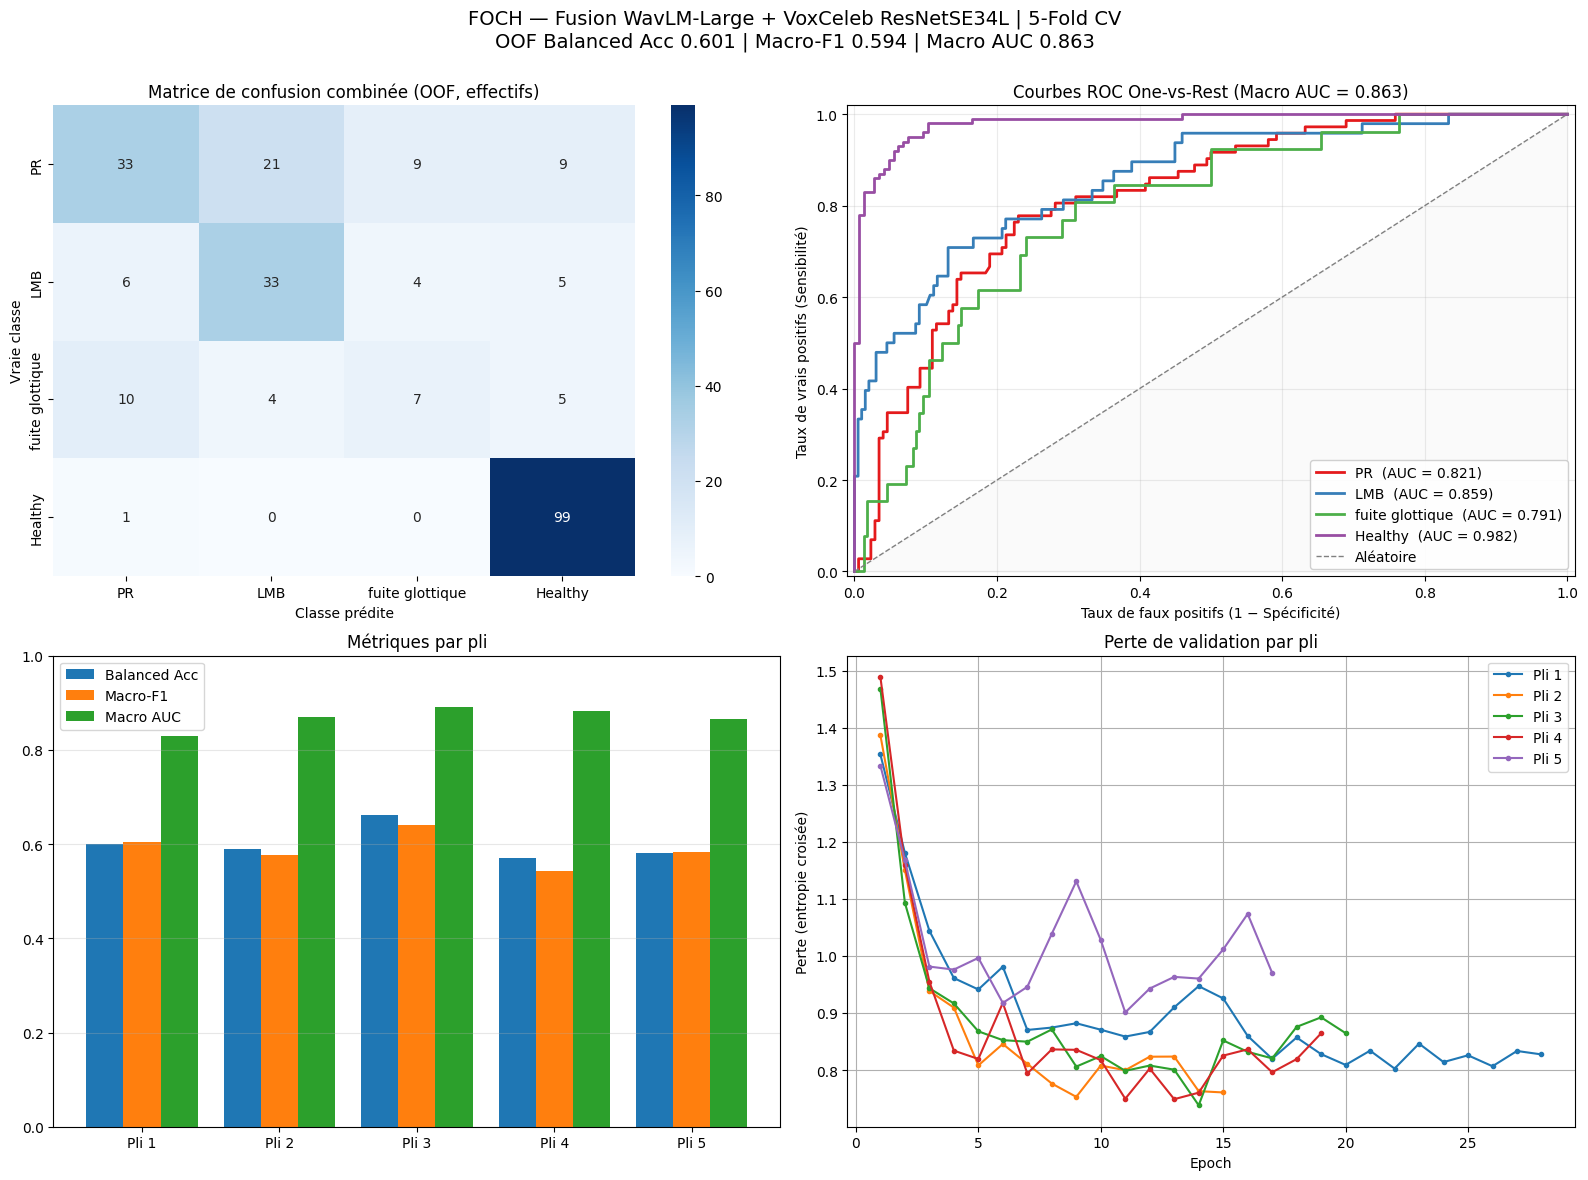


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_métriques :
  • wavlm_voxceleb_kfold_aug_dashboard.png
  • wavlm_voxceleb_kfold_aug_metrics.json
  • wavlm_voxceleb_kfold_aug_confusion.csv
  • wavlm_voxceleb_kfold_aug_fold_metrics.csv


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation agrégée out-of-fold (K-Fold)
# ═══════════════════════════════════════════════════════════════════════════
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc as sk_auc)
from sklearn.preprocessing import label_binarize

assert (oof_labels >= 0).all(), "Des enregistrements n\'ont pas été évalués !"

# ── Métriques agrégées ────────────────────────────────────────────────────────
print('Rapport de classification agrégé (out-of-fold) :')
print('\n' + classification_report(oof_labels, oof_preds, labels=labels_idx,
                                    target_names=CLASSES, digits=3, zero_division=0))
oof_bal = balanced_accuracy_score(oof_labels, oof_preds)
oof_mf1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)
try:
    oof_auc = roc_auc_score(oof_labels, oof_probs, multi_class='ovr',
                            average='macro', labels=labels_idx)
except ValueError:
    oof_auc = float('nan')

mean_bal, std_bal = fold_df['balanced_accuracy'].mean(), fold_df['balanced_accuracy'].std()
mean_f1,  std_f1  = fold_df['macro_f1'].mean(),          fold_df['macro_f1'].std()
mean_auc, std_auc = fold_df['macro_auc_ovr'].mean(),     fold_df['macro_auc_ovr'].std()
print(f'OOF global        — Balanced Acc {oof_bal:.4f} | Macro-F1 {oof_mf1:.4f} | Macro AUC {oof_auc:.4f}')
print(f'Moyenne par pli   — Balanced Acc {mean_bal:.4f}±{std_bal:.4f} | '
      f'Macro-F1 {mean_f1:.4f}±{std_f1:.4f} | Macro AUC {mean_auc:.4f}±{std_auc:.4f}')

# ── ROC par classe (One-vs-Rest) ──────────────────────────────────────────────
oof_labels_bin = label_binarize(oof_labels, classes=labels_idx)   # (n, 4)

# ── Tableau de bord 2×2 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'FOCH — Fusion WavLM-Large + VoxCeleb ResNetSE34L | {K_FOLDS}-Fold CV\n'
             f'OOF Balanced Acc {oof_bal:.3f} | Macro-F1 {oof_mf1:.3f} | Macro AUC {oof_auc:.3f}',
             fontsize=14)

# ── [0, 0] Matrice de confusion (effectifs bruts) ─────────────────────────────
cm = confusion_matrix(oof_labels, oof_preds, labels=labels_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[0, 0].set_title('Matrice de confusion combinée (OOF, effectifs)')
axes[0, 0].set_ylabel('Vraie classe')
axes[0, 0].set_xlabel('Classe prédite')

# ── [0, 1] Courbes ROC OvR par classe ────────────────────────────────────────
_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']   # rouge, bleu, vert, violet
for i, (cls, col) in enumerate(zip(CLASSES, _colors)):
    fpr, tpr, _ = roc_curve(oof_labels_bin[:, i], oof_probs[:, i])
    auc_i = sk_auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {auc_i:.3f})')

axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Aléatoire')
axes[0, 1].fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
axes[0, 1].set_xlim([-0.01, 1.01])
axes[0, 1].set_ylim([-0.01, 1.02])
axes[0, 1].set_xlabel('Taux de faux positifs (1 − Spécificité)')
axes[0, 1].set_ylabel('Taux de vrais positifs (Sensibilité)')
axes[0, 1].set_title(f'Courbes ROC One-vs-Rest (Macro AUC = {oof_auc:.3f})')
axes[0, 1].legend(loc='lower right', framealpha=0.9)
axes[0, 1].grid(True, alpha=0.25)

# ── [1, 0] Métriques par pli ──────────────────────────────────────────────────
x = np.arange(K_FOLDS); w = 0.27
axes[1, 0].bar(x - w, fold_df['balanced_accuracy'], w, label='Balanced Acc')
axes[1, 0].bar(x,     fold_df['macro_f1'],          w, label='Macro-F1')
axes[1, 0].bar(x + w, fold_df['macro_auc_ovr'],     w, label='Macro AUC')
axes[1, 0].set_title('Métriques par pli')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f'Pli {i+1}' for i in range(K_FOLDS)])
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()
axes[1, 0].grid(True, axis='y', alpha=0.3)

# ── [1, 1] Perte de validation par pli ────────────────────────────────────────
for k, hist in enumerate(fold_curves):
    axes[1, 1].plot(range(1, len(hist) + 1), hist, 'o-', label=f'Pli {k+1}', markersize=3)
axes[1, 1].set_title('Perte de validation par pli')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Perte (entropie croisée)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts ──────────────────────────────────────────────────
report_dict = classification_report(oof_labels, oof_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name':               RUN_NAME,
    'architecture':           f'DualBranchFusion (WavLM-Large + VoxCeleb ResNetSE34L, emb_dim={VOXCELEB_EMB_DIM})',
    'cv':                     f'StratifiedKFold(n_splits={K_FOLDS})',
    'oof_balanced_accuracy':  oof_bal,
    'oof_macro_f1':           oof_mf1,
    'oof_macro_auc_ovr':      oof_auc,
    'mean_balanced_accuracy': mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':          mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':     mean_auc, 'std_macro_auc_ovr':     std_auc,
    'per_fold':               fold_rows,
    'per_class_oof':          report_dict,
    'classes':                CLASSES,
    'n_total':                int(len(df)),
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')
fold_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_fold_metrics.csv'), index=False)

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json')
print(f'  • {RUN_NAME}_confusion.csv')
print(f'  • {RUN_NAME}_fold_metrics.csv')


## 9. Ensembling des K modèles à l'inférence

Les K checkpoints produits par la validation croisée sont chargés l'un après l'autre et leurs **probabilités sont moyennées** (soft voting). Cette stratégie d'ensemble exploite la diversité introduite par les K plis distincts.

**Deux évaluations sont présentées :**

| Évaluation | Biais | Utilité |
|---|---|---|
| **OOF** (Cellule 7) | Non biaisé — chaque exemple prédit une seule fois, par le modèle qui ne l'a jamais vu | Estimation fidèle de la performance en production |
| **Ensemble full** (cette cellule) | Optimiste — tous les K modèles votent sur chaque exemple, y compris ceux vus en train | Indique le gain maximal théorique de l'ensemble sur le jeu interne |

> 💡 **Cas d'usage production** : pointer `full_loader` vers un jeu de test indépendant (jamais vu) pour obtenir une évaluation réellement non biaisée de l'ensemble.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 9 — Ensembling des K modèles à l'inférence (soft voting)
# ═══════════════════════════════════════════════════════════════════════════
import json
from sklearn.metrics import classification_report

def ensemble_predict(dataloader, ckpt_paths, temperature=ENSEMBLE_TEMPERATURE):
    """Predict class probabilities by averaging K models (soft voting).

    Each checkpoint is loaded on GPU, runs inference, then is deleted to free
    memory before the next. The final probabilities are the arithmetic mean of
    individual model softmax outputs.

    Args:
        dataloader    : DataLoader for the data to predict (shuffle=False).
        ckpt_paths    : list of checkpoint paths (.pt files).
        temperature   : softmax temperature; >1 = softer, <1 = sharper. Default 1.0.

    Returns:
        probs  : np.ndarray [N, NUM_LABELS] — averaged probabilities.
        preds  : np.ndarray [N]             — argmax predictions.
    """
    all_model_probs = []

    for ckpt_path in ckpt_paths:
        if not os.path.isfile(ckpt_path):
            print(f'  ⚠  Checkpoint introuvable : {ckpt_path} — ignoré.')
            continue

        # Build model with same architecture, load saved weights.
        # strict=False tolerates requires_grad mismatches that can arise from
        # progressive unfreezing (the saved state_dict records parameter values
        # regardless of requires_grad; the fresh model starts fully frozen).
        m = build_model().to(device)
        m.load_state_dict(torch.load(ckpt_path, map_location=device), strict=False)
        m.eval()

        fold_probs = []
        with torch.no_grad():
            for xb, wb, _ in dataloader:
                xb = xb.to(device); wb = wb.to(device)
                logits = m(xb, wb) / temperature
                fold_probs.append(F.softmax(logits, dim=1).cpu().numpy())

        all_model_probs.append(np.concatenate(fold_probs))   # [N, NUM_LABELS]
        print(f'  ✓ {os.path.basename(ckpt_path)}')

        del m
        gc.collect()
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    if not all_model_probs:
        raise RuntimeError('Aucun checkpoint trouvé — exécutez d\'abord la Cellule 7.')

    probs = np.mean(all_model_probs, axis=0)          # mean pooling across models
    preds = probs.argmax(axis=1)
    print(f'\n  Ensemble : {len(all_model_probs)}/{K_FOLDS} modèles moyennés '
          f'(température = {temperature}).')
    return probs, preds


# ── Inférence ensemble sur le jeu complet ────────────────────────────────────
ckpt_paths  = [os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_fold{k+1}_best.pt')
               for k in range(K_FOLDS)]
full_loader = DataLoader(FochVowelDataset(df, processor), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=0)

print('Inférence ensemble (K modèles) :')
ens_probs, ens_preds = ensemble_predict(full_loader, ckpt_paths)
ens_labels = df['label'].to_numpy()

ens_bal = balanced_accuracy_score(ens_labels, ens_preds)
ens_mf1 = f1_score(ens_labels, ens_preds, average='macro', zero_division=0)
try:
    ens_auc = roc_auc_score(ens_labels, ens_probs, multi_class='ovr',
                            average='macro', labels=labels_idx)
except ValueError:
    ens_auc = float('nan')

print('\nRapport de classification — Ensemble full (jeu complet, OPTIMISTE) :')
print(classification_report(ens_labels, ens_preds, labels=labels_idx,
                             target_names=CLASSES, digits=3, zero_division=0))
print(f'Ensemble Balanced Acc {ens_bal:.4f} | Macro-F1 {ens_mf1:.4f} | Macro AUC {ens_auc:.4f}')

# ── Comparaison OOF (non biaisé) vs Ensemble full (optimiste) ────────────────
print(f'\n{"─"*60}')
print('Comparaison OOF (non biaisé) vs Ensemble full (optimiste) :')
print(f'{"─"*60}')
for label_, oof_val, ens_val in [
    ('Balanced Accuracy', oof_bal, ens_bal),
    ('Macro-F1',          oof_mf1, ens_mf1),
    ('Macro AUC',         oof_auc, ens_auc),
]:
    delta = ens_val - oof_val
    print(f'  {label_:<20} : OOF {oof_val:.4f} | Ensemble {ens_val:.4f} | Δ {delta:+.4f}')

# ── Sauvegarde ───────────────────────────────────────────────────────────────
ens_metrics = {
    'run_name': RUN_NAME,
    'ensemble_n_models': len(ckpt_paths),
    'ensemble_temperature': ENSEMBLE_TEMPERATURE,
    'ens_balanced_accuracy': ens_bal,
    'ens_macro_f1': ens_mf1,
    'ens_macro_auc_ovr': ens_auc,
    'note': 'Ensemble full — optimiste (entraînés sur K-1 plis, prédits sur tout le jeu)',
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_ensemble_metrics.json'), 'w',
          encoding='utf-8') as f:
    json.dump(ens_metrics, f, ensure_ascii=False, indent=2, default=float)
print(f'\nArtefact sauvegardé : {RUN_NAME}_ensemble_metrics.json')

## 10. Synthèse des améliorations (v2)

Ce notebook implémente quatre améliorations sur le modèle de fusion bi-branche de référence (Notebook 6).

---

### Dégel progressif de ResNetSE34L

ResNetSE34L démarre entièrement gelé. Les blocs sont débloqués de haut (couches fines) en bas (couches grossières) toutes les quelques epochs :

```
Epoch ≥ 4  → attention + bn5 + fc6 + bn6  (SAP pooling + tête)       LR × 0.50
Epoch ≥ 6  → layer4                        (dernier bloc résiduel)     LR × 0.10
Epoch ≥ 9  → layer3                        (avant-dernier bloc)         LR × 0.05
Epoch ≥ 13 → layer2 + layer1 + stem        (couches inférieures)       LR × 0.02
```

Bénéfice : évite de « détruire » les features VoxCeleb dès les premières epochs, quand la tête de classification n'est pas encore calibrée.

---

### Dégel progressif de WavLM-Large

WavLM-Large (24 couches Transformer) subit le même traitement, avec un LR encore plus faible pour préserver les représentations audio générales pré-entraînées :

```
Epoch ≥ 6  → couches 18-23 + feature_projection                        LR × 0.020
Epoch ≥ 11 → couches 12-17                                              LR × 0.010
Epoch ≥ 17 → couches 0-11 + feature_extractor (CNN)                    LR × 0.002
```

---

### SpecAugment sur les features CNN de WavLM

WavLM opère sur la forme d'onde brute — il n'y a pas de spectrogramme. Le SpecAugment est appliqué sur la **sortie du CNN feature extractor** `[B, T', 512]`, entre la convolution et le Transformer :

- **Masques temporels** : `SA_N_TIME_MASKS × SA_TIME_MASK_PARAM` frames consecutives mises à zéro dans T′ ≈ 200
- **Masques de canaux** : `SA_N_FREQ_MASKS × SA_FREQ_MASK_PARAM` canaux consécutifs mis à zéro dans les 512 features CNN

L'implémentation utilise une multiplication `features × mask` (non in-place) pour que les gradients puissent traverser les couches Transformer partiellement dégelées.

---

### Ensembling des K modèles (soft voting)

Après la boucle K-Fold, les K checkpoints sont rechargés l'un après l'autre et leurs probabilités softmax sont **moyennées**. L'ensemble réduit la variance des prédictions.

> **Rappel de lecture** : l'évaluation OOF (Cellule 7) reste la référence non biaisée. L'évaluation ensemble full (Cellule 9) est optimiste car les modèles votent sur des exemples qu'ils ont vus en entraînement. Pour de vraies nouvelles données, pointer `full_loader` vers un jeu de test indépendant.

---

**Ordre d'exécution : 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10**